In [1]:
# =============================================
# Project 09 — Retail Demand Prediction Engine
# Prajwal Kondala | IIT KGP → AI/ML Engineer
# Date: April 24, 2026
# Business Question:
# "How much will this Rossmann store sell on a given day?"
# Dataset: Rossmann Store Sales (Kaggle!)
# =============================================

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

print("All libraries imported!")
print("Pandas version:", pd.__version__)
print("NumPy version:", np.__version__)

All libraries imported!
Pandas version: 2.2.2
NumPy version: 2.0.2


In [3]:

train = pd.read_csv('/content/train.csv',
                    low_memory=False)
store = pd.read_csv('/content/store.csv')

print("Train shape:", train.shape)
print("Store shape:", store.shape)
print("\nTrain columns:", train.columns.tolist())
print("Store columns:", store.columns.tolist())

Train shape: (1017209, 9)
Store shape: (1115, 10)

Train columns: ['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo', 'StateHoliday', 'SchoolHoliday']
Store columns: ['Store', 'StoreType', 'Assortment', 'CompetitionDistance', 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval']


In [4]:
# First 5 rows of both!
print("TRAIN DATA — First 5 rows:")
print(train.head())
print("\nSTORE DATA — First 5 rows:")
print(store.head())

TRAIN DATA — First 5 rows:
   Store  DayOfWeek        Date  Sales  Customers  Open  Promo StateHoliday  \
0      1          5  2015-07-31   5263        555     1      1            0   
1      2          5  2015-07-31   6064        625     1      1            0   
2      3          5  2015-07-31   8314        821     1      1            0   
3      4          5  2015-07-31  13995       1498     1      1            0   
4      5          5  2015-07-31   4822        559     1      1            0   

   SchoolHoliday  
0              1  
1              1  
2              1  
3              1  
4              1  

STORE DATA — First 5 rows:
   Store StoreType Assortment  CompetitionDistance  CompetitionOpenSinceMonth  \
0      1         c          a               1270.0                        9.0   
1      2         a          a                570.0                       11.0   
2      3         a          a              14130.0                       12.0   
3      4         c          c   

In [5]:
print("TRAIN DATA STATISTICS:")
print(train.describe())
print("\nMissing values in train:")
print(train.isnull().sum())
print("\nMissing values in store:")
print(store.isnull().sum())

TRAIN DATA STATISTICS:
              Store     DayOfWeek         Sales     Customers          Open  \
count  1.017209e+06  1.017209e+06  1.017209e+06  1.017209e+06  1.017209e+06   
mean   5.584297e+02  3.998341e+00  5.773819e+03  6.331459e+02  8.301067e-01   
std    3.219087e+02  1.997391e+00  3.849926e+03  4.644117e+02  3.755392e-01   
min    1.000000e+00  1.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00   
25%    2.800000e+02  2.000000e+00  3.727000e+03  4.050000e+02  1.000000e+00   
50%    5.580000e+02  4.000000e+00  5.744000e+03  6.090000e+02  1.000000e+00   
75%    8.380000e+02  6.000000e+00  7.856000e+03  8.370000e+02  1.000000e+00   
max    1.115000e+03  7.000000e+00  4.155100e+04  7.388000e+03  1.000000e+00   

              Promo  SchoolHoliday  
count  1.017209e+06   1.017209e+06  
mean   3.815145e-01   1.786467e-01  
std    4.857586e-01   3.830564e-01  
min    0.000000e+00   0.000000e+00  
25%    0.000000e+00   0.000000e+00  
50%    0.000000e+00   0.000000e+00  
75%   

In [6]:
# Closed-store days produce zero sales by definition.
# Since the objective is to estimate demand during operating days,
# exclude closed days from model training.

print("Rows where store is closed:",
      (train['Open'] == 0).sum())
print("Rows where Sales = 0:",
      (train['Sales'] == 0).sum())

# Remove closed store days!
train = train[train['Open'] == 1]
train = train[train['Sales'] > 0]

print("\nAfter removing closed days:")
print("Train shape:", train.shape)
print("Min Sales now:", train['Sales'].min())

Rows where store is closed: 172817
Rows where Sales = 0: 172871

After removing closed days:
Train shape: (844338, 9)
Min Sales now: 46


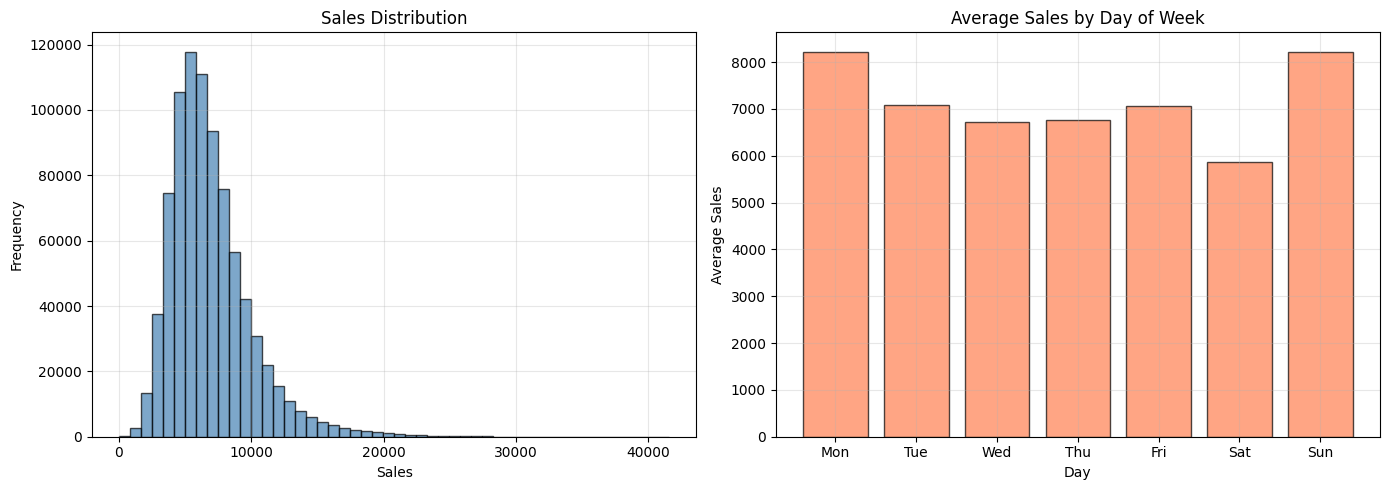

Chart saved!


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sales distribution
axes[0].hist(train['Sales'], bins=50,
             color='steelblue', edgecolor='black',
             alpha=0.7)
axes[0].set_title('Sales Distribution')
axes[0].set_xlabel('Sales')
axes[0].set_ylabel('Frequency')
axes[0].grid(True, alpha=0.3)

# Sales by Day of Week
dow_sales = train.groupby('DayOfWeek')['Sales'].mean()
days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
axes[1].bar(days, dow_sales.values,
            color='coral', edgecolor='black', alpha=0.7)
axes[1].set_title('Average Sales by Day of Week')
axes[1].set_xlabel('Day')
axes[1].set_ylabel('Average Sales')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('sales_distribution.png', bbox_inches='tight')
plt.show()
print("Chart saved!")

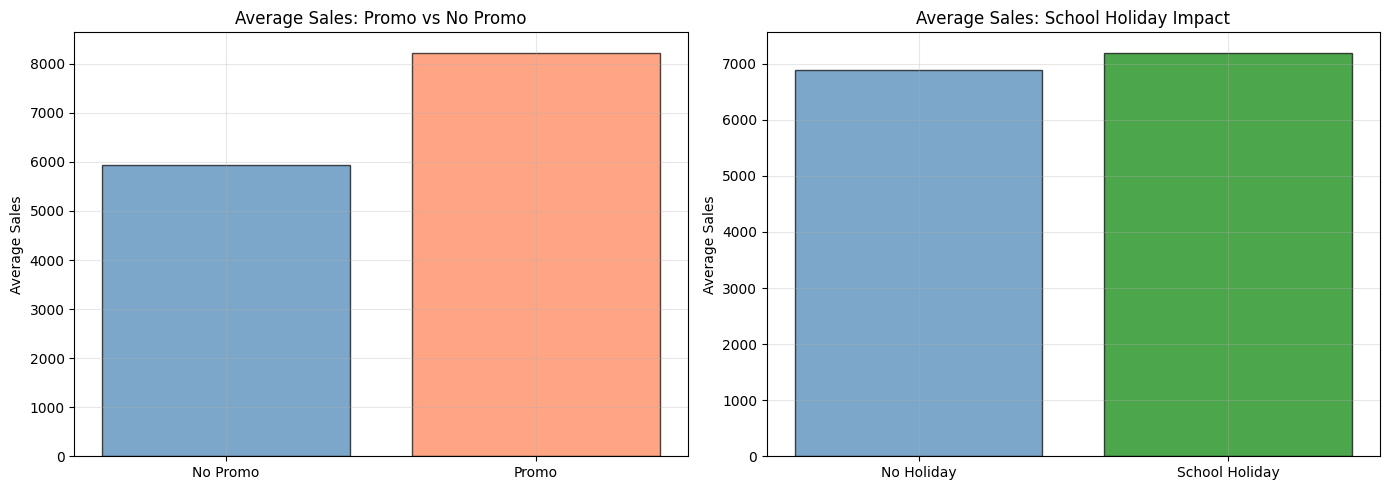

Chart saved!


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Promo vs No Promo
promo_sales = train.groupby('Promo')['Sales'].mean()
axes[0].bar(['No Promo', 'Promo'],
            promo_sales.values,
            color=['steelblue', 'coral'],
            edgecolor='black', alpha=0.7)
axes[0].set_title('Average Sales: Promo vs No Promo')
axes[0].set_ylabel('Average Sales')
axes[0].grid(True, alpha=0.3)

# School Holiday impact
school_sales = train.groupby('SchoolHoliday')['Sales'].mean()
axes[1].bar(['No Holiday', 'School Holiday'],
            school_sales.values,
            color=['steelblue', 'green'],
            edgecolor='black', alpha=0.7)
axes[1].set_title('Average Sales: School Holiday Impact')
axes[1].set_ylabel('Average Sales')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('promo_analysis.png', bbox_inches='tight')
plt.show()
print("Chart saved!")

In [9]:
# Reload store fresh
store = pd.read_csv('/content/store.csv')

# Fill missing values with business logic!
store['CompetitionDistance'] = store[
    'CompetitionDistance'].fillna(
    store['CompetitionDistance'].max())

store['Promo2SinceWeek']  = store['Promo2SinceWeek'].fillna(0)
store['Promo2SinceYear']  = store['Promo2SinceYear'].fillna(0)
store['PromoInterval']    = store['PromoInterval'].fillna('None')
store['CompetitionOpenSinceMonth'] = store[
    'CompetitionOpenSinceMonth'].fillna(0)
store['CompetitionOpenSinceYear']  = store[
    'CompetitionOpenSinceYear'].fillna(0)

print("Store missing values after filling:")
print(store.isnull().sum())

# Merge train with store!
df = pd.merge(train, store, on='Store', how='left')

print("\nMerged shape:", df.shape)
print("StoreType unique:", df['StoreType'].unique())
print("Assortment unique:", df['Assortment'].unique())

Store missing values after filling:
Store                        0
StoreType                    0
Assortment                   0
CompetitionDistance          0
CompetitionOpenSinceMonth    0
CompetitionOpenSinceYear     0
Promo2                       0
Promo2SinceWeek              0
Promo2SinceYear              0
PromoInterval                0
dtype: int64

Merged shape: (844338, 18)
StoreType unique: ['c' 'a' 'd' 'b']
Assortment unique: ['a' 'c' 'b']


In [10]:
# Convert Date to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Extract date features!
df['Year']         = df['Date'].dt.year
df['Month']        = df['Date'].dt.month
df['Day']          = df['Date'].dt.day
df['WeekOfYear']   = df['Date'].dt.isocalendar().week.astype(int)
df['IsWeekend']    = (df['DayOfWeek'] >= 6).astype(int)
df['IsMonthStart'] = df['Date'].dt.is_month_start.astype(int)
df['IsMonthEnd']   = df['Date'].dt.is_month_end.astype(int)

print("Date features added!")
print("Shape:", df.shape)
print("\nSample:")
print(df[['Date', 'Year', 'Month', 'Day',
          'WeekOfYear', 'IsWeekend']].head(3))

Date features added!
Shape: (844338, 25)

Sample:
        Date  Year  Month  Day  WeekOfYear  IsWeekend
0 2015-07-31  2015      7   31          31          0
1 2015-07-31  2015      7   31          31          0
2 2015-07-31  2015      7   31          31          0


In [11]:
# Check values BEFORE mapping!
print("Before encoding:")
print("StateHoliday unique:", df['StateHoliday'].unique())
print("StoreType unique:", df['StoreType'].unique())
print("Assortment unique:", df['Assortment'].unique())

# Encode!
df['StateHoliday'] = df['StateHoliday'].map(
    {'0': 0, 0: 0, 'a': 1, 'b': 2, 'c': 3}
).fillna(0)

df['StoreType'] = df['StoreType'].map(
    {'a': 1, 'b': 2, 'c': 3, 'd': 4}
)

df['Assortment'] = df['Assortment'].map(
    {'a': 1, 'b': 2, 'c': 3}
)

print("\nAfter encoding:")
print("StateHoliday unique:", df['StateHoliday'].unique())
print("StoreType unique:", df['StoreType'].unique())
print("Assortment unique:", df['Assortment'].unique())
print("\nAny NaN?")
print(df[['StateHoliday','StoreType',
          'Assortment']].isnull().sum())

Before encoding:
StateHoliday unique: ['0' 'a' 'b' 'c']
StoreType unique: ['c' 'a' 'd' 'b']
Assortment unique: ['a' 'c' 'b']

After encoding:
StateHoliday unique: [0 1 2 3]
StoreType unique: [3 1 4 2]
Assortment unique: [1 3 2]

Any NaN?
StateHoliday    0
StoreType       0
Assortment      0
dtype: int64


In [12]:
features = [
    'Store', 'DayOfWeek', 'Promo',
    'StateHoliday', 'SchoolHoliday',
    'StoreType', 'Assortment',
    'CompetitionDistance',
    'Promo2', 'Year', 'Month', 'Day',
    'WeekOfYear', 'IsWeekend',
    'IsMonthStart', 'IsMonthEnd'
]

target = 'Sales'

X = df[features]
y = df[target]

print("Features selected:", len(features))
print("Feature names:", features)
print("\nX shape:", X.shape)
print("y shape:", y.shape)
print("\nAny missing in X?")
print(X.isnull().sum())

Features selected: 16
Feature names: ['Store', 'DayOfWeek', 'Promo', 'StateHoliday', 'SchoolHoliday', 'StoreType', 'Assortment', 'CompetitionDistance', 'Promo2', 'Year', 'Month', 'Day', 'WeekOfYear', 'IsWeekend', 'IsMonthStart', 'IsMonthEnd']

X shape: (844338, 16)
y shape: (844338,)

Any missing in X?
Store                  0
DayOfWeek              0
Promo                  0
StateHoliday           0
SchoolHoliday          0
StoreType              0
Assortment             0
CompetitionDistance    0
Promo2                 0
Year                   0
Month                  0
Day                    0
WeekOfYear             0
IsWeekend              0
IsMonthStart           0
IsMonthEnd             0
dtype: int64


In [13]:
from sklearn.model_selection import train_test_split

# ALWAYS random_state=42!
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training set:", X_train.shape)
print("Testing set :", X_test.shape)
print("\nTrain sales mean:", y_train.mean().round(2))
print("Test sales mean :", y_test.mean().round(2))

Training set: (675470, 16)
Testing set : (168868, 16)

Train sales mean: 6955.27
Test sales mean : 6958.7


In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# fit_transform on training ONLY!
X_train_scaled = scaler.fit_transform(X_train)

# Only transform on test!
X_test_scaled = scaler.transform(X_test)

print("Scaling done!")
print("Train mean (should be ~0):",
      X_train_scaled.mean(axis=0).round(2))
print("Train std (should be ~1):",
      X_train_scaled.std(axis=0).round(2))

Scaling done!
Train mean (should be ~0): [-0.  0. -0. -0. -0.  0. -0.  0. -0.  0. -0. -0. -0. -0. -0.  0.]
Train std (should be ~1): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [15]:
def predict(X, theta):
    return X @ theta

def compute_cost(X, y, theta):
    m = len(y)
    predictions = predict(X, theta)
    errors = predictions - y
    cost = (1 / (2 * m)) * np.sum(errors ** 2)
    return cost

def gradient_descent(X, y, theta, learning_rate, epochs):
    m = len(y)
    cost_history = []
    for epoch in range(epochs):
        predictions = predict(X, theta)
        errors = predictions - y
        gradient = (1/m) * X.T @ errors
        theta = theta - learning_rate * gradient
        cost = compute_cost(X, y, theta)
        cost_history.append(cost)
        if epoch % 100 == 0:
            print(f"Epoch {epoch}: Cost = {cost:.4f}")
    return theta, cost_history

# Add bias column
X_train_b = np.c_[np.ones((len(X_train_scaled), 1)),
                   X_train_scaled]
X_test_b  = np.c_[np.ones((len(X_test_scaled), 1)),
                   X_test_scaled]

# Initialize!
theta = np.zeros(X_train_b.shape[1])

print("Functions defined!")
print("Theta shape:", theta.shape)
print("X_train_b shape:", X_train_b.shape)
print("\nStarting gradient descent...")
print("675,470 rows — may take 2-3 minutes!")

learning_rate = 0.01
epochs = 500

theta_trained, cost_history = gradient_descent(
    X_train_b, y_train.values,
    theta, learning_rate, epochs
)

print("\nScratch training complete!")

Functions defined!
Theta shape: (17,)
X_train_b shape: (675470, 17)

Starting gradient descent...
675,470 rows — may take 2-3 minutes!
Epoch 0: Cost = 28498074.6791
Epoch 100: Cost = 7193303.1235
Epoch 200: Cost = 4346274.0013
Epoch 300: Cost = 3954386.0056
Epoch 400: Cost = 3897284.0969

Scratch training complete!


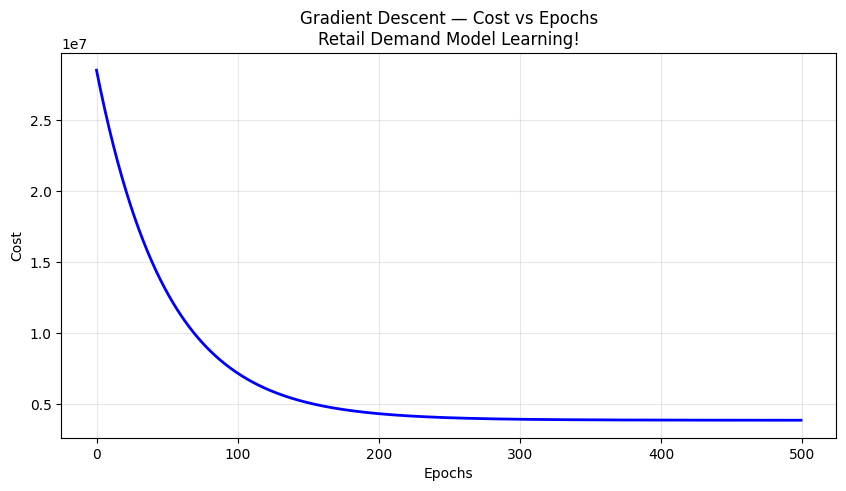

Chart saved!


In [16]:
plt.figure(figsize=(10, 5))
plt.plot(range(epochs), cost_history,
         color='blue', linewidth=2)
plt.xlabel('Epochs')
plt.ylabel('Cost')
plt.title('Gradient Descent — Cost vs Epochs\n'
          'Retail Demand Model Learning!')
plt.grid(True, alpha=0.3)
plt.savefig('cost_convergence.png',
            bbox_inches='tight')
plt.show()
print("Chart saved!")

In [17]:
y_pred_scratch = predict(X_test_b, theta_trained)

mse_scratch  = np.mean((y_pred_scratch - y_test.values)**2)
rmse_scratch = np.sqrt(mse_scratch)
r2_scratch   = 1 - (np.sum((y_test.values - y_pred_scratch)**2) /
                    np.sum((y_test.values - y_test.values.mean())**2))

print("=" * 40)
print("SCRATCH MODEL RESULTS")
print("=" * 40)
print(f"RMSE : {rmse_scratch:.2f}")
print(f"R²   : {r2_scratch:.4f}")
print("=" * 40)

SCRATCH MODEL RESULTS
RMSE : 2788.34
R²   : 0.1943


In [18]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

model = LinearRegression()
model.fit(X_train_scaled, y_train)

y_pred_sk = model.predict(X_test_scaled)

mse_sk  = mean_squared_error(y_test, y_pred_sk)
rmse_sk = np.sqrt(mse_sk)
r2_sk   = r2_score(y_test, y_pred_sk)

print("=" * 40)
print("sklearn MODEL RESULTS")
print("=" * 40)
print(f"RMSE : {rmse_sk:.2f}")
print(f"R²   : {r2_sk:.4f}")
print("=" * 40)

sklearn MODEL RESULTS
RMSE : 2786.86
R²   : 0.1951


Feature Importance (sorted):
                Feature  Coefficient
2                 Promo  1116.652703
8                Promo2  -415.105120
1             DayOfWeek  -403.936873
6            Assortment   389.547973
13            IsWeekend   271.579495
7   CompetitionDistance  -231.941127
15           IsMonthEnd   230.142719
9                  Year   152.023993
12           WeekOfYear   140.180907
10                Month   112.786839
14         IsMonthStart    94.077448
5             StoreType   -80.435042
11                  Day   -71.724312
3          StateHoliday    68.610994
4         SchoolHoliday    55.749330
0                 Store    16.082161


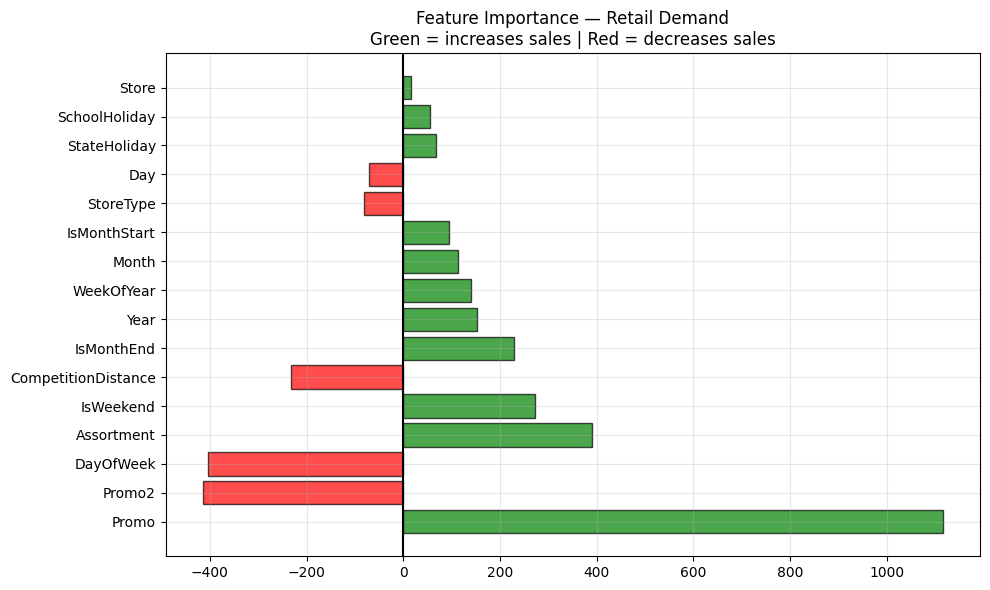

Chart saved!


In [19]:
importance = pd.DataFrame({
    'Feature': features,
    'Coefficient': model.coef_
})

importance = importance.reindex(
    importance['Coefficient'].abs().sort_values(
        ascending=False).index
)

print("Feature Importance (sorted):")
print(importance.to_string())

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['green' if c > 0 else 'red'
          for c in importance['Coefficient']]
ax.barh(importance['Feature'],
        importance['Coefficient'],
        color=colors, alpha=0.7,
        edgecolor='black')
ax.axvline(x=0, color='black', linewidth=1.5)
ax.set_title('Feature Importance — Retail Demand\n'
             'Green = increases sales | '
             'Red = decreases sales')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('feature_importance.png',
            bbox_inches='tight')
plt.show()
print("Chart saved!")

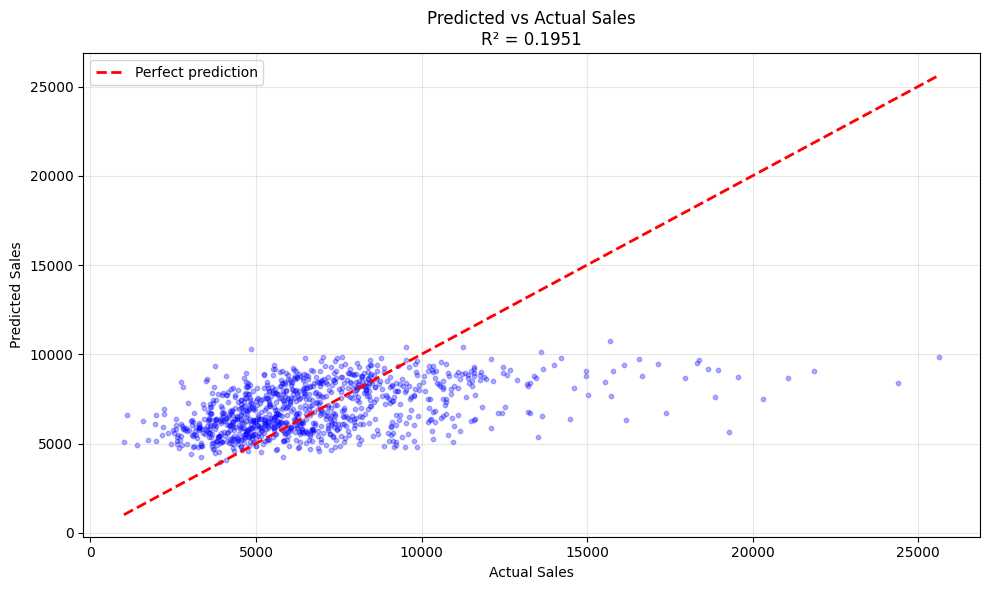

Chart saved!


In [20]:
sample_idx = np.random.choice(len(y_test), 1000,
                               replace=False)
y_sample   = y_test.values[sample_idx]
pred_sample = y_pred_sk[sample_idx]

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(y_sample, pred_sample,
           alpha=0.3, color='blue', s=10)

min_val = min(y_sample.min(), pred_sample.min())
max_val = max(y_sample.max(), pred_sample.max())
ax.plot([min_val, max_val], [min_val, max_val],
        'r--', linewidth=2, label='Perfect prediction')

ax.set_xlabel('Actual Sales')
ax.set_ylabel('Predicted Sales')
ax.set_title(f'Predicted vs Actual Sales\n'
             f'R² = {r2_sk:.4f}')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('predictions_vs_actual.png',
            bbox_inches='tight')
plt.show()
print("Chart saved!")

In [21]:
print("=" * 55)
print("COMPLETE PROJECT 09 SUMMARY")
print("=" * 55)
print(f"\n{'Method':<20} {'R²':>8} {'RMSE':>10}")
print("-" * 55)
print(f"{'NumPy Scratch':<20} {r2_scratch:>8.4f} "
      f"{rmse_scratch:>10.2f}")
print(f"{'sklearn':<20} {r2_sk:>8.4f} "
      f"{rmse_sk:>10.2f}")
print("=" * 55)
print(f"\nDataset: Rossmann Store Sales (Kaggle!)")
print(f"Training rows : {len(X_train):,}")
print(f"Test rows     : {len(X_test):,}")
print(f"Features used : {len(features)}")
print(f"\nKey insight:")
print(f"Linear model establishes BASELINE!")
print(f"Non-linear patterns → XGBoost Week 11!")
print(f"Expected R² with XGBoost → 0.85+!")

COMPLETE PROJECT 09 SUMMARY

Method                     R²       RMSE
-------------------------------------------------------
NumPy Scratch          0.1943    2788.34
sklearn                0.1951    2786.86

Dataset: Rossmann Store Sales (Kaggle!)
Training rows : 675,470
Test rows     : 168,868
Features used : 16

Key insight:
Linear model establishes BASELINE!
Non-linear patterns → XGBoost Week 11!
Expected R² with XGBoost → 0.85+!


In [22]:
import pickle

with open('model.pkl', 'wb') as f:
    pickle.dump(model, f)

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("✅ model.pkl saved!")
print("✅ scaler.pkl saved!")


✅ model.pkl saved!
✅ scaler.pkl saved!


In [23]:
# Load and process test.csv for Kaggle submission!
test = pd.read_csv('/content/test.csv')
store_test = pd.read_csv('/content/store.csv')

# Same preprocessing as train!
# Fill missing in store
store_test['CompetitionDistance'] = store_test[
    'CompetitionDistance'].fillna(
    store_test['CompetitionDistance'].max())
store_test['Promo2SinceWeek']  = store_test['Promo2SinceWeek'].fillna(0)
store_test['Promo2SinceYear']  = store_test['Promo2SinceYear'].fillna(0)
store_test['PromoInterval']    = store_test['PromoInterval'].fillna('None')
store_test['CompetitionOpenSinceMonth'] = store_test[
    'CompetitionOpenSinceMonth'].fillna(0)
store_test['CompetitionOpenSinceYear']  = store_test[
    'CompetitionOpenSinceYear'].fillna(0)

# Merge test with store
test_merged = pd.merge(test, store_test,
                       on='Store', how='left')

# Handle Open NaN in test
test_merged['Open'] = test_merged['Open'].fillna(1)

# Date features
test_merged['Date'] = pd.to_datetime(test_merged['Date'])
test_merged['Year']       = test_merged['Date'].dt.year
test_merged['Month']      = test_merged['Date'].dt.month
test_merged['Day']        = test_merged['Date'].dt.day
test_merged['WeekOfYear'] = test_merged['Date'].dt.isocalendar().week.astype(int)
test_merged['IsWeekend']  = (test_merged['DayOfWeek'] >= 6).astype(int)
test_merged['IsMonthStart'] = test_merged['Date'].dt.is_month_start.astype(int)
test_merged['IsMonthEnd']   = test_merged['Date'].dt.is_month_end.astype(int)

# Encode categoricals
test_merged['StateHoliday'] = test_merged['StateHoliday'].map(
    {'0': 0, 0: 0, 'a': 1, 'b': 2, 'c': 3}
).fillna(0)
test_merged['StoreType']  = test_merged['StoreType'].map(
    {'a': 1, 'b': 2, 'c': 3, 'd': 4})
test_merged['Assortment'] = test_merged['Assortment'].map(
    {'a': 1, 'b': 2, 'c': 3})

# Select same features
X_kaggle = test_merged[features]

# Scale using SAME scaler!
X_kaggle_scaled = scaler.transform(X_kaggle)

# Predict!
kaggle_predictions = model.predict(X_kaggle_scaled)

# Negative predictions → set to 0!
kaggle_predictions = np.clip(kaggle_predictions, 0, None)

# Create submission file
submission = pd.DataFrame({
    'Id': test_merged['Id'],
    'Sales': kaggle_predictions
})

submission.to_csv('submission.csv', index=False)
print("✅ submission.csv created!")
print("Shape:", submission.shape)
print(submission.head())
print("\nDownload submission.csv from Colab Files!")
print("Upload to Kaggle → rossmann-store-sales → Submit!")

✅ submission.csv created!
Shape: (41088, 2)
   Id        Sales
0   1  8430.495626
1   2  7371.257660
2   3  8719.821848
3   4  8380.131639
4   5  9312.913623

Download submission.csv from Colab Files!
Upload to Kaggle → rossmann-store-sales → Submit!
